<a href="https://colab.research.google.com/github/derewor/scRNA-Analysis-from-mouse-brain/blob/main/scRNA_seq_mouse_brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install scanpy -q
!pip install typing_extensions>=4.10.0 -q

In [3]:
!pip uninstall -y scanpy anndata typing_extensions -q
!pip install typing_extensions>=4.10.0 -q
!pip install scanpy -q
import scanpy as sc

In [4]:
counts_df = pd.read_csv('/content/brain_counts.csv')

In [5]:
metadata_df = pd.read_csv('/content/brain_metadata.csv')

In [6]:
adata_norm = sc.read('/content/glioblastoma_normalized.h5ad')

In [7]:
adata_raw = sc.read('/content/glioblastoma_raw.h5ad')

In [8]:
pmbc_df = sc.read('/content/pbmc3k.h5ad')

In [9]:
adata_raw

AnnData object with n_obs × n_vars = 1853 × 7683
    obs: 'disease_state', 'plate_id', 'tissue', 'patient_id', 'cell_type', 'neoplastic_state', 'diagnosis'
    layers: None

In [10]:
metadata_df = metadata_df.set_index('cell')
metadata_df.head()

,cell_ontology_class,subtissue,mouse.sex,mouse.id,plate.barcode
cell,,,,,
A1.B003290.3_38_F.1.1,astrocyte,Striatum,F,3_38_F,B003290
A1.B003728.3_56_F.1.1,astrocyte,Striatum,F,3_56_F,B003728
A1.MAA000560.3_10_M.1.1,oligodendrocyte,Cortex,M,3_10_M,MAA000560
A1.MAA000564.3_10_M.1.1,endothelial cell,Striatum,M,3_10_M,MAA000564
A1.MAA000923.3_9_M.1.1,astrocyte,Hippocampus,M,3_9_M,MAA000923


In [11]:
# Observe the top few rows of the counts dataframe.
print(counts_df.shape)
# set the first column as index.
counts_df = counts_df.set_index('Unnamed: 0')
#counts_df = counts_df.rename(columns={'Unnamed: 0': 'cell_id'})
counts_df.head()

(3401, 23434)


,0610005C13Rik,0610007C21Rik,0610007L01Rik,0610007N19Rik,0610007P08Rik,0610007P14Rik,0610007P22Rik,0610008F07Rik,0610009B14Rik,0610009B22Rik,...,Zxdb,Zxdc,Zyg11a,Zyg11b,Zyx,Zzef1,Zzz3,a,l7Rn6,zsGreen_transgene
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
A1.B003290.3_38_F.1.1,0,125,16,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,54,0
A1.B003728.3_56_F.1.1,0,0,0,0,0,324,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1.MAA000560.3_10_M.1.1,0,348,0,0,0,5,0,0,0,0,...,0,0,0,0,0,195,0,0,113,0
A1.MAA000564.3_10_M.1.1,0,41,36,0,0,24,0,0,0,14,...,0,0,0,0,125,0,1,0,0,0
A1.MAA000923.3_9_M.1.1,0,53,0,0,0,0,0,0,0,0,...,0,0,0,81,0,0,0,0,0,0


#### **1. Merge the count and metadata frame into one .AnnData file.**
#### **2. Insert a columns that describes weather a gene is spike in or not. Spike in RNAs have a name id that start with "ERCC"**
#### **3. Calculate the Quality Control metrics from the Scanpy preprocessing library.**
#### **4. Filiter out cells with very low number of reads per cell.**
#### **5. Filter out cells which expressed genes in very low quantity.**
#### **6. remove cells which contain high proportion of spike in ERCC counts eg. > 10%.**
#### **7. Normalize the filitered data using log or scaling.**
#### **8. Extract the highly variable genes and reduce the dimension using PCA.**
#### **9. Cluster the cells based on distance and assign labels (kmeans).**
#### **10.Identify unique top 10 genes that differenciates the cells from other cell types as markers.**


## **1. Create .AnnData by merging the count_df and metadata_df.**

In [12]:
# use the scanpy library. The cell_id in both df should be an index.
adata = sc.AnnData(X=counts_df, obs=metadata_df)

In [13]:
# visualize the data.
adata.X

array([[  0, 125,  16, ...,   0,  54,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0, 348,   0, ...,   0, 113,   0],
       ...,
       [  0, 135,  41, ...,   0,  45,   0],
       [  0, 129,  54, ...,   0,  57,   0],
       [  0,   1,   0, ...,   0,   0,   0]], shape=(3401, 23433))

In [14]:
adata.var.head()

""
0610005C13Rik
0610007C21Rik
0610007L01Rik
0610007N19Rik
0610007P08Rik


In [15]:
adata

AnnData object with n_obs × n_vars = 3401 × 23433
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode'
    layers: None

##**2. To label spike-ins based on the var_name. It starts with ERCC.**

In [16]:
# write a code that loops through the var_names and label true when there is ERCC.
spike_in = {}
for gene_names in adata.var_names:
  if 'ERCC' in gene_names:
    spike_in[gene_names] = True
  else:
    spike_in[gene_names] = False

adata.var['ERCC'] = pd.Series(spike_in)
adata.var.head()

,ERCC
0610005C13Rik,False
0610007C21Rik,False
0610007L01Rik,False
0610007N19Rik,False
0610007P08Rik,False


In [17]:
# determine the number of spike_in samples.
n_spikeins = adata.var.ERCC.value_counts().reset_index()
n_spikeins # 92 samples are identified as spikeins.

,ERCC,count
0,False,23341
1,True,92


In [18]:
# query and view the rop 5 ERCC samples.
ercc = adata.var.query("ERCC == True")
ercc.head()

,ERCC
ERCC-00002,True
ERCC-00003,True
ERCC-00004,True
ERCC-00009,True
ERCC-00012,True


##**3. Control the quality of the data.**

In [19]:
# The quality of the cells and genes are analysed based on the spike in.
# This is done using the quality cotrol metrics built with in the scanpy preprocess module.
qc = sc.pp.calculate_qc_metrics(adata, qc_vars=['ERCC'], inplace=True) # if inplace is false, it creates two dataframes for cell and gene metrics.
# This stores the cells metrics in the adata.obs dataframe and the gene metrics in the adata.var df.

In [20]:
# view the cell metrics
adata.obs.head()

,cell_ontology_class,subtissue,mouse.sex,mouse.id,plate.barcode,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_ERCC,log1p_total_counts_ERCC,pct_counts_ERCC
cell,,,,,,,,,,,,,,,,
A1.B003290.3_38_F.1.1,astrocyte,Striatum,F,3_38_F,B003290,3359,8.119696,390075,12.874097,25.884766,32.847017,42.219573,59.472666,10201,9.230339,2.615138
A1.B003728.3_56_F.1.1,astrocyte,Striatum,F,3_56_F,B003728,1718,7.449498,776439,13.562475,43.051933,52.912721,65.313309,87.315423,67351,11.117688,8.674345
A1.MAA000560.3_10_M.1.1,oligodendrocyte,Cortex,M,3_10_M,MAA000560,3910,8.271548,1616087,14.295519,44.066006,51.514553,60.164211,74.451190,29870,10.304643,1.848292
A1.MAA000564.3_10_M.1.1,endothelial cell,Striatum,M,3_10_M,MAA000564,4352,8.378621,360004,12.793873,41.650926,48.958623,56.997422,69.736170,2592,7.860571,0.719992
A1.MAA000923.3_9_M.1.1,astrocyte,Hippocampus,M,3_9_M,MAA000923,2248,7.718241,290282,12.578612,63.392494,69.136908,77.168753,90.522320,11002,9.305923,3.790108


In [21]:
# view the gene metrics.
adata.var.head()

,ERCC,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
0610005C13Rik,False,28,0.118201,0.111721,99.176713,402,5.998937
0610007C21Rik,False,2399,206.211996,5.333742,29.461923,701327,13.460731
0610007L01Rik,False,961,35.938547,3.609256,71.743605,122227,11.713643
0610007N19Rik,False,272,6.498383,2.014687,92.002352,22101,10.003423
0610007P08Rik,False,582,16.328727,2.852366,82.887386,55534,10.924769


##**Cell Quality Control.**

###**Visulalize different features.**

<Figure size 300x400 with 0 Axes>

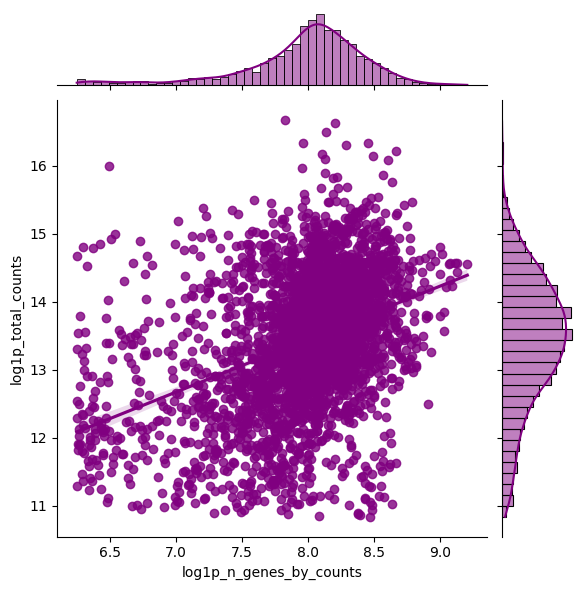

In [22]:
# plot and visualize the distribution on the log values of n_genes and total counts using the jointplot.
plt.figure(figsize=(3,4))
sns.jointplot(data=adata.obs, x='log1p_n_genes_by_counts', y='log1p_total_counts', kind='reg', color='purple')
#plt.ylim(0, None)
#plt.xlim(0, None)
plt.show()

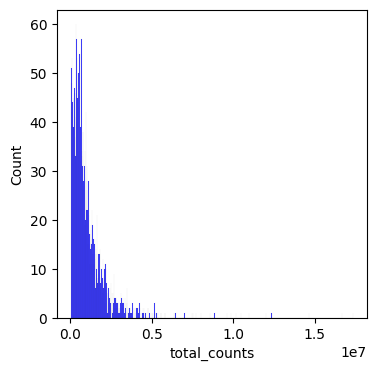

In [23]:
# observe the the total counts of genes per cells from the observarion.
plt.figure(figsize=(4,4))
sns.histplot(data=adata.obs, x='total_counts', bins=1000, color='blue')
plt.show()

In [24]:
# determine cells with total counts of reads less than 50000.
num_dead_cells = sum(adata.obs['total_counts'] < 50000)
num_dead_cells # this suggests that there are no dead cells or cells with fewer than 50000 reads.


0

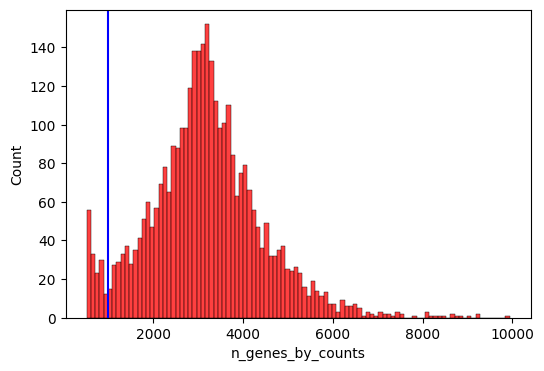

In [25]:
# determine the distribution of the number of unique genes identified in each cell. The n_genes_by_counts give the values.
plt.rcParams["figure.figsize"] = (6, 4)
sns.histplot(data=adata.obs, x='n_genes_by_counts', bins=100, color='red')
plt.axvline(x=1000, color='blue')
plt.show()

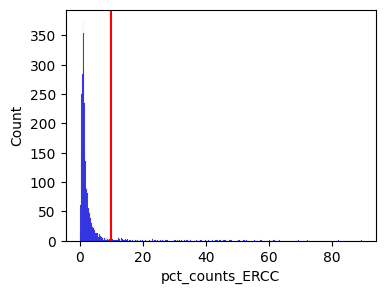

In [26]:
# visualize the distribution of the percent_ercc_distribution.
plt.rcParams["figure.figsize"] = (4, 3)
sns.histplot(data=adata.obs, x='pct_counts_ERCC', bins=500, color='blue')
plt.axvline(x=10, color='red') # cells containig 10 or more percent of ERCC genes are poor quality.
plt.show()

###**Filtering poor quality cells based on the above observations.**

In [27]:
# Cells having 10 or more percent of ERCC genes are poor quality and needs to be removed.
adata_filtered = adata.obs.query("pct_counts_ERCC < 10")
adata_filtered.head()
print(adata_filtered.shape)

(3218, 16)


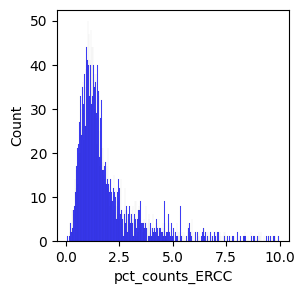

In [28]:
# plot the data to visualize the distribution after filtering cells with high ERCC percentage.
plt.figure(figsize=(3,3))
sns.histplot(data=adata_filtered, x='pct_counts_ERCC', bins=500, color='blue')
plt.show()

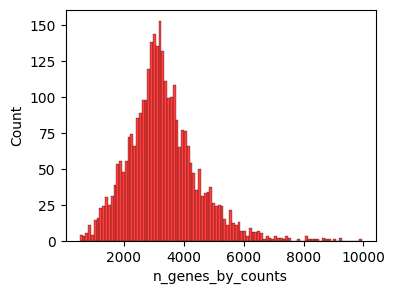

In [29]:
# plot and visualize the number of unique genes by cell after filtering for high ERCC.
plt.figure(figsize=(4,3))
sns.histplot(data=adata_filtered, x='n_genes_by_counts', bins=100, color='red')
plt.show() # Interestingly most cells with low number of genes per cell were also authomatically removed.

In [30]:
# remove cells having n_genes count less than 750 per cell.
adata_filtered1 = adata_filtered[adata_filtered['n_genes_by_counts'] >= 750]
print(adata_filtered.shape)
print(adata_filtered1.shape)

(3218, 16)
(3210, 16)


In [31]:
# filter the adata anndata to contain only cells with in the adata_filtered1 dataframe.
adata_filt = adata[adata.obs.index.isin(adata_filtered1.index)]
adata_filt

View of AnnData object with n_obs × n_vars = 3210 × 23433
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ERCC', 'log1p_total_counts_ERCC', 'pct_counts_ERCC'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None

In [32]:
adata_filt.write('adata_clean.h5ad')

##**Gene Quality Control.**

In [33]:
# view the .var attribute of adata.
adata_filt.var.head()

,ERCC,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
0610005C13Rik,False,28,0.118201,0.111721,99.176713,402,5.998937
0610007C21Rik,False,2399,206.211996,5.333742,29.461923,701327,13.460731
0610007L01Rik,False,961,35.938547,3.609256,71.743605,122227,11.713643
0610007N19Rik,False,272,6.498383,2.014687,92.002352,22101,10.003423
0610007P08Rik,False,582,16.328727,2.852366,82.887386,55534,10.924769


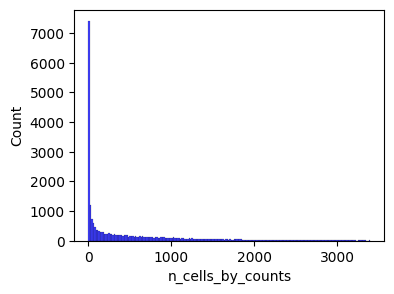

In [34]:
# Visualize the distribution of the n_cells_by_counts for expressing genes.
plt.figure(figsize=(4,3))
sns.histplot(data=adata_filt.var, x='n_cells_by_counts', bins=200, color='blue')
plt.show()

In [35]:
# dertermine the numer of gene which are expressing in less that 2 cells.
rare_expression = sum(adata_filt.var['n_cells_by_counts'] < 2)
rare_expression

3969

In [36]:
# determine the number of genes whose total_count of readings are less than 10.
low_counts = sum(adata_filt.var['total_counts'] < 10)
low_counts

4432

In [37]:
# filter the genes using the filter_genes method of the scanpy preprocess module.
print('start_data: \n', adata_filt)
sc.pp.filter_genes(data=adata_filt, min_cells=2)
sc.pp.filter_genes(data=adata_filt, min_counts=10)
print('end_data: \n', adata_filt) # nearly 15k genes were removed as low quality.

start_data: 
 AnnData object with n_obs × n_vars = 3210 × 23433
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ERCC', 'log1p_total_counts_ERCC', 'pct_counts_ERCC'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None
end_data: 
 AnnData object with n_obs × n_vars = 3210 × 18585
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ERCC', 'log1p_total_counts_ERCC', 'pct_counts_ERC

In [38]:
adata_filt.write('adata_filt2.h5ad')

##**4. Normalization and PCA in scRNA**

In [39]:
# view the shape of the AnnData. The anndata has 18585 features (genes). For better clustering the dimension need to be reduced.
adata_filt.X.shape

(3210, 18585)

In [40]:
adata_filt1 = adata_filt.copy()

###**Dimension Reduction**

In [41]:
# use pca to reduce the dimension. PCA is a method stored in the scapy preprocess module.
sc.pp.pca(adata_filt1)

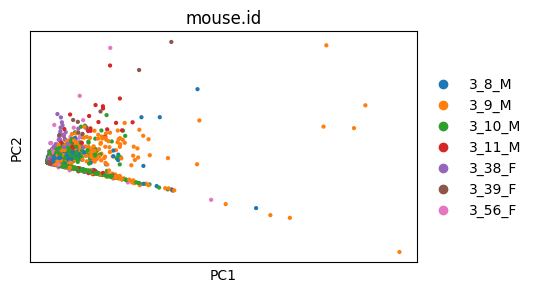

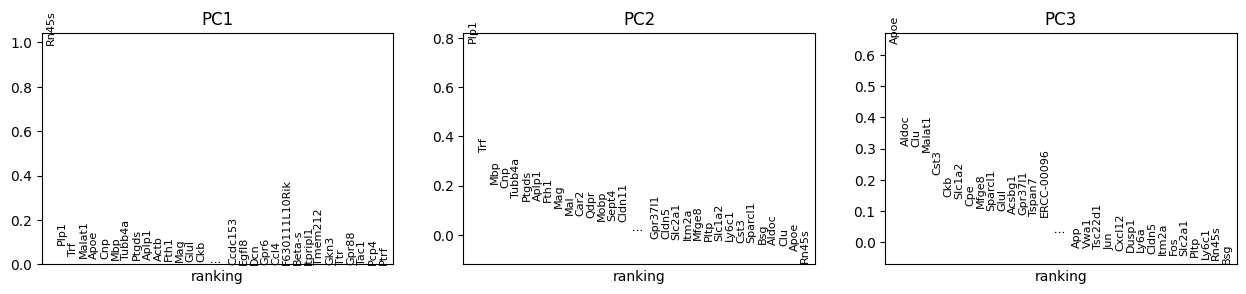

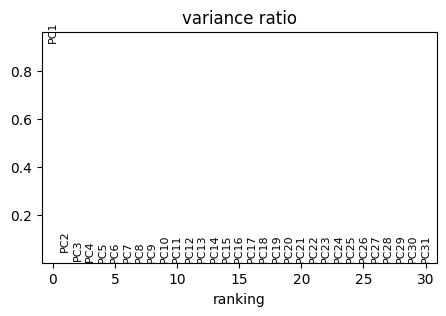

In [42]:
# view the pca outputs.
plt.rcParams["figure.figsize"] = (5, 3) # runtime configuration parameters.
sc.pl.pca_overview(adata_filt1, color='mouse.id')
plt.show()

### PCA1 appears to explain almost all variation between cells. Suggesting a dominant effect of some genes.

In [43]:
# View the pca values and shape.
display(adata_filt1.varm['PCs'])
display(adata_filt1.varm['PCs'].shape)

array([[ 3.90559261e-07, -1.04339245e-06,  5.01953361e-06, ...,
        -1.24506693e-05,  5.49261469e-06,  8.34793111e-06],
       [ 5.04033929e-04,  7.00641257e-04,  3.00280268e-03, ...,
        -2.04545576e-03, -1.42752459e-02, -6.23745219e-03],
       [ 9.63757867e-05, -1.56630619e-04, -1.34476791e-04, ...,
        -5.91278025e-03, -5.15749157e-03, -6.89312314e-03],
       ...,
       [ 6.28575389e-05,  8.21345351e-05,  1.00800709e-04, ...,
         1.86724802e-03, -1.76053726e-03,  5.49906520e-03],
       [ 4.99979287e-08, -2.79155057e-07, -4.34064565e-07, ...,
         4.06686790e-06,  4.97050236e-06,  3.38387423e-06],
       [ 2.24475899e-04, -1.46511584e-04,  1.68350801e-03, ...,
         1.52033607e-03,  4.50203441e-03, -4.31560279e-03]],
      shape=(18585, 50))

(18585, 50)

In [44]:
print(adata_filt1.obsm['X_pca'])
print(adata_filt1.obsm['X_pca'].shape)

[[-1.8424262e+05 -1.3552747e+04  2.3973022e+03 ... -1.5601984e+03
   6.8164844e+02  4.2361938e+01]
 [-1.6474755e+05 -1.9324459e+04  5.1527844e+04 ...  1.3176158e+03
   3.1714888e+03  2.7396455e+03]
 [ 9.0670752e+03  8.0857055e+04  6.4449331e+03 ...  2.2792837e+03
  -4.0856451e+02 -5.2319739e+02]
 ...
 [-1.8081212e+05 -1.4364995e+04 -4.0254963e+03 ...  6.0876678e+02
   7.2786078e+02 -5.0457767e+02]
 [-4.4792086e+04  1.3990004e+04 -3.5562534e+03 ...  6.0536475e+02
  -4.4264130e+01 -4.8476660e+02]
 [-1.8489636e+05 -1.4003842e+04  2.1832595e+03 ...  9.8997139e+01
   7.8757973e+01  4.2160725e+01]]
(3210, 50)


###**Normalization**

#### There might be variation between the cells. So, unwanted variation between samples need to be avoided. For that normalization is required. Coverting to Count Per Million (CPM) is the best way of doing it.

In [45]:
# copy the adata_filt
adata_cpm = adata_filt1.copy()
# store the raw data for the adata_cpm
adata_cpm.raw = adata_cpm
adata_cpm.X = adata_cpm.X.astype(float)
# Normalize the data by using the normalize_per_cell method of the scanpy preprocess module.
sc.pp.normalize_per_cell(adata_cpm, counts_per_cell_after=1e6)

### Reduce the dimention of the normalized data

In [46]:
# PCA reduction
sc.pp.pca(adata_cpm)

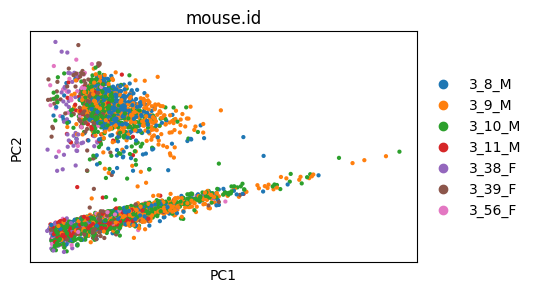

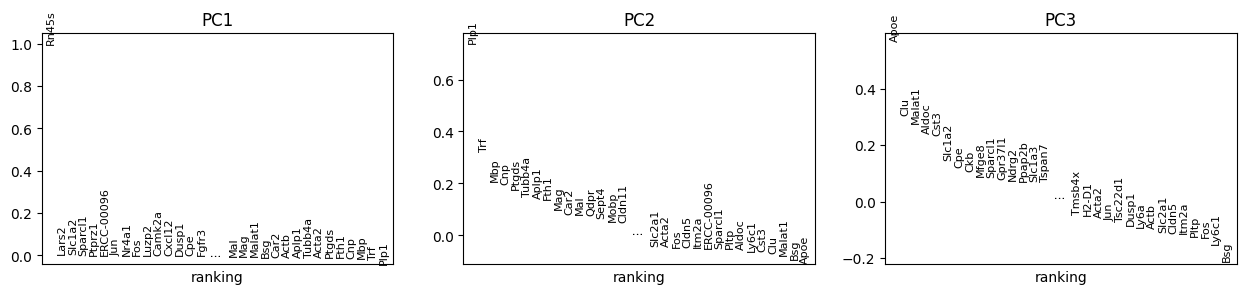

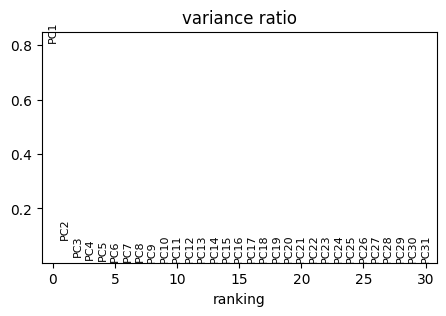

In [47]:
# plot and visualize the pca reduced data.
plt.rcParams["figure.figsize"] = (5, 3)
sc.pl.pca_overview(adata_cpm, color='mouse.id')
plt.show()

### PCA1 still contributed the greatest discitnction between cells. As in this analysis Rn45s shows very high expression and probably dominates the effect of other genes. So romove it.

In [48]:
# remove the highly expressing Rn45s from the var.
wo_rn45s = adata_cpm.var.index != 'Rn45s'
adata_wo_rn45s = adata_cpm[:, wo_rn45s]
adata_wo_rn45s

View of AnnData object with n_obs × n_vars = 3210 × 18584
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ERCC', 'log1p_total_counts_ERCC', 'pct_counts_ERCC', 'n_counts'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'n_counts'
    uns: 'pca', 'mouse.id_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None

In [49]:
# reduce the dimetion of the new filtered anndata.
sc.pp.pca(adata_wo_rn45s)


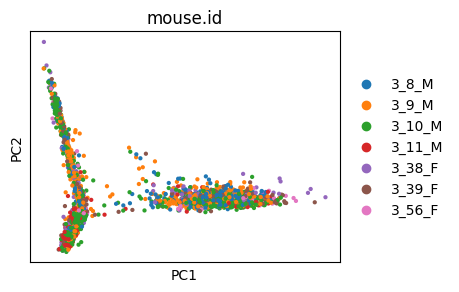

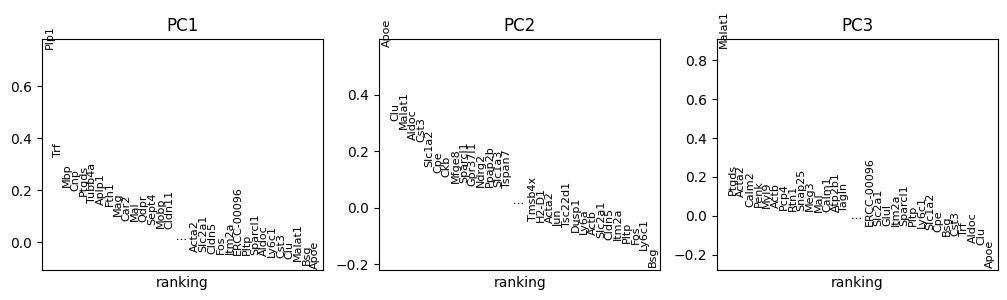

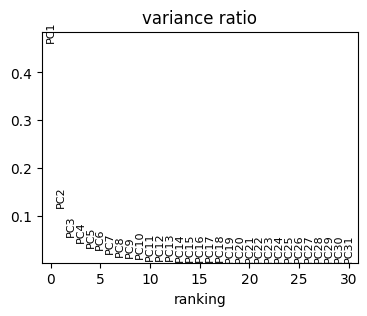

In [50]:
# Visualize the pca
plt.rcParams["figure.figsize"] = (4,3)
sc.pl.pca_overview(adata_wo_rn45s, color='mouse.id')
plt.show()

### Now the PCA1 contribution appears to be more realistic and PCA2 also show more contribution.

In [51]:
adata_wo_rn45s.uns['pca']['variance_ratio'][0:10]

array([0.46206935, 0.11829837, 0.05715984, 0.04347198, 0.03428659,
       0.0286928 , 0.0202788 , 0.01529989, 0.01306298, 0.00993058])

### There is still some dominant effect of some genes. This can be further improved by scaling or log transformation.

In [52]:
# first normalize the cells using the normalize total method of the scanpy preprocessing module.
adata_norm = adata_filt.copy()
sc.pp.normalize_total(adata_norm, target_sum = 1e6)
# log transform the adata_filt.
sc.pp.log1p(adata_norm)
# Select the top 3000 highly variable genes.
sc.pp.highly_variable_genes(adata_norm, n_top_genes=2500)
adata_hvg = adata_norm[:, adata_norm.var.highly_variable].copy()
# scale the data using z-score.
sc.pp.scale(adata_hvg)
# perform pca on the adata_hvg
sc.pp.pca(adata_hvg)

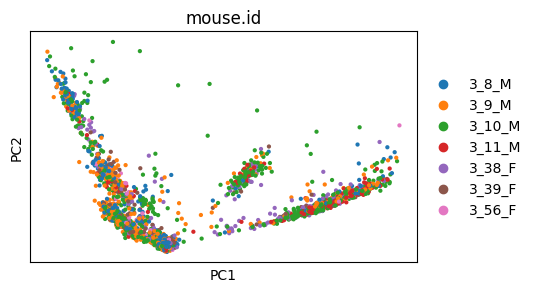

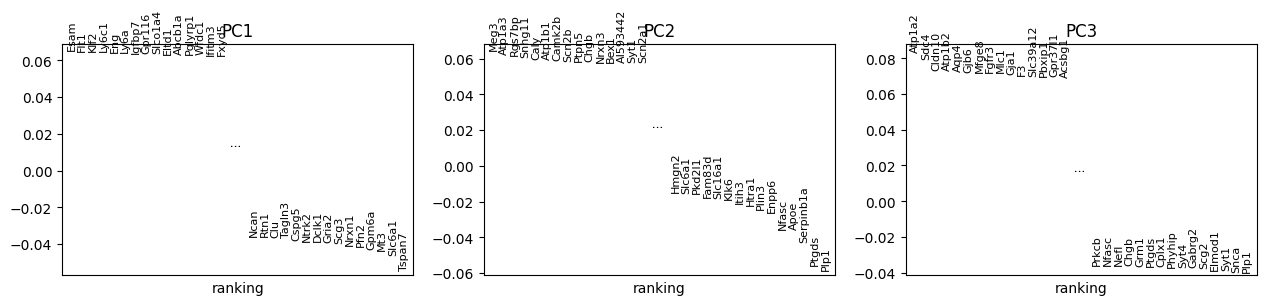

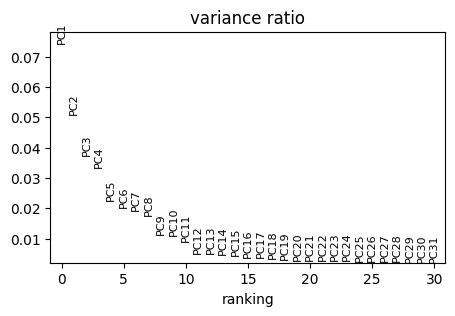

In [53]:
plt.rcParams["figure.figsize"] = (5,3)
sc.pl.pca_overview(adata_hvg, color='mouse.id')
plt.show()

In [54]:
# observe the top 10 pca values
sum(adata_hvg.uns['pca']['variance_ratio'][0:30])

np.float32(0.36895362)

##**5. Clustering cells**

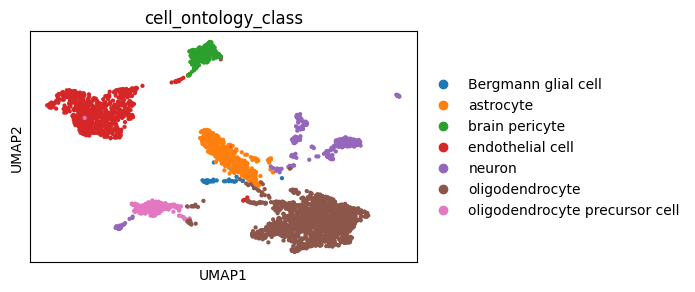

In [55]:
# Use the neighbors tool to connect cells from the normalized and highly variable genes containing dataframe.
sc.pp.neighbors(adata_hvg)
# use the scanpy tools method to cluster the cells based on diatance using umap
sc.tl.umap(adata_hvg, min_dist=0.5, spread=1.0, random_state=42, n_components=2)
# plot and visualize the graph
sc.pl.umap(adata_hvg, color='cell_ontology_class')

In [56]:
# trying a different clustering tool kmeans.
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

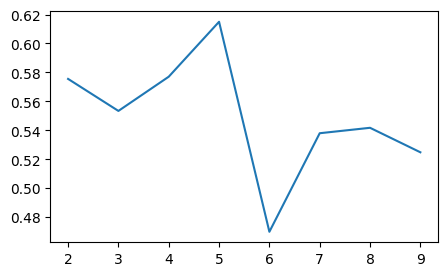

In [57]:
# determine the appropriate number of cluster by using silhuoette score.
sil_score = []
for i in range(2,10):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(adata_hvg.obsm['X_umap'])
  sil_score.append(silhouette_score(adata_hvg.obsm['X_umap'], kmeans.labels_))

plt.plot(range(2,10), sil_score)
plt.show()

### **The silhouette_score graph shows that 6 clusters are the appropriate.**

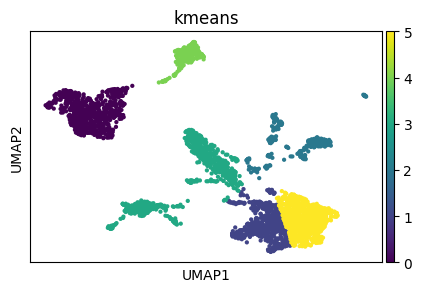

In [65]:
# extract the umap_coordinates for each cell.
umap_coordinates = adata_hvg.obsm['X_umap']
# fit the umap corrdinates to kmeans.
kmeans = KMeans(n_clusters=6, random_state=42).fit(umap_coordinates)
# retreive the labels and add to the metadata. The metadata is in the observarion.
adata_hvg.obs['kmeans'] = kmeans.labels_
# plot the results, Ploting the umap with the color as the cluster label
sc.pl.umap(adata_hvg, color='kmeans')

In [59]:
adata_hvg.obs.kmeans.value_counts()

kmeans
5    835
3    704
0    674
1    558
2    265
4    174
Name: count, dtype: int64

##**6. Diffenetial expression of genes between clusters.**

In [60]:
# use the original filtered but unnormalized data which was saved above as adata_filt2.
#adata_filt2 = sc.read('/content/adata_filt2.h5ad')

In [61]:
adata_filt

AnnData object with n_obs × n_vars = 3210 × 18585
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ERCC', 'log1p_total_counts_ERCC', 'pct_counts_ERCC'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'n_counts'
    uns: 'pca', 'mouse.id_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None

In [66]:
# create a raw dataframe
raw = pd.DataFrame(adata_filt.X, index=adata_filt.obs_names, columns=adata_filt.var_names)

In [67]:
raw.head()

,0610005C13Rik,0610007C21Rik,0610007L01Rik,0610007N19Rik,0610007P08Rik,0610007P14Rik,0610007P22Rik,0610009B14Rik,0610009B22Rik,0610009D07Rik,...,Zwint,Zxda,Zxdb,Zxdc,Zyg11b,Zyx,Zzef1,Zzz3,a,l7Rn6
cell,,,,,,,,,,,,,,,,,,,,,
A1.B003290.3_38_F.1.1,0,125,16,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,54
A1.B003728.3_56_F.1.1,0,0,0,0,0,324,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1.MAA000560.3_10_M.1.1,0,348,0,0,0,5,0,0,0,316,...,266,0,0,0,0,0,195,0,0,113
A1.MAA000564.3_10_M.1.1,0,41,36,0,0,24,0,0,14,0,...,0,0,0,0,0,125,0,1,0,0
A1.MAA000923.3_9_M.1.1,0,53,0,0,0,0,0,0,0,0,...,0,0,0,0,81,0,0,0,0,0


In [86]:
# rank the top10 genes differencially expression within cell groups.
sc.tl.rank_genes_groups(adata_filt, groupby='cell_ontology_class', method='t-test_overestim_var', n_genes=10)

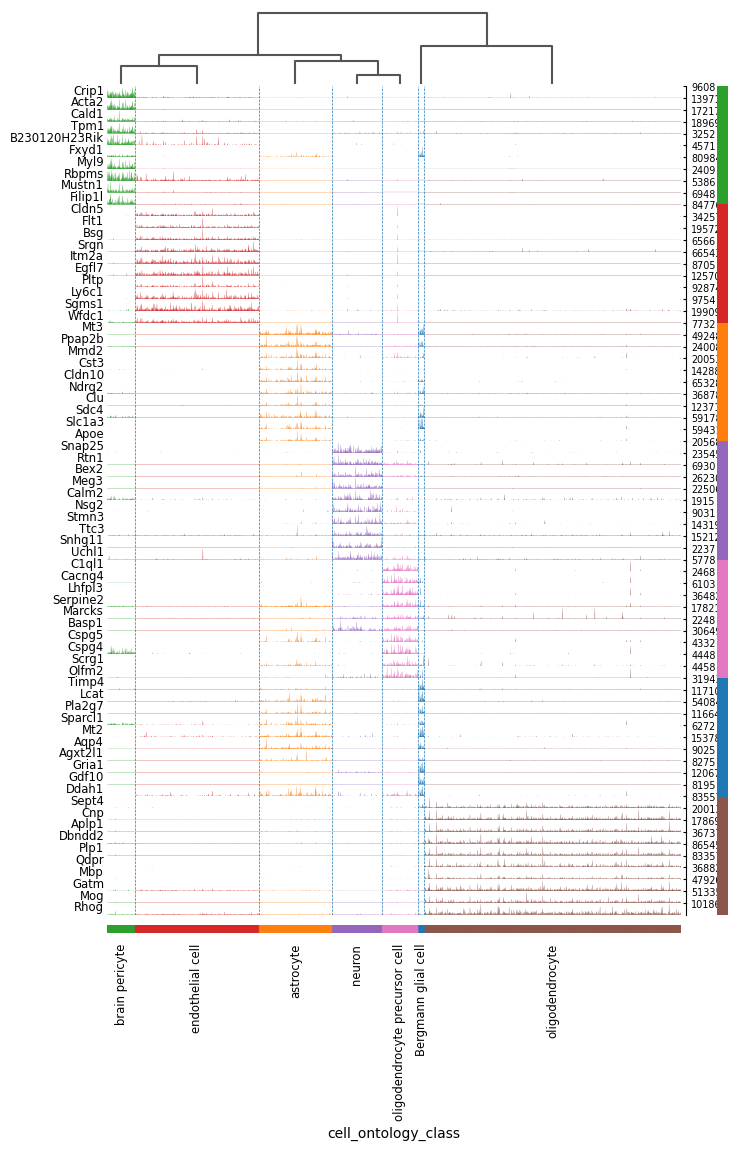

In [82]:
# plot the ranking of genes using heatmap
sc.pl.rank_genes_groups_tracksplot(adata_filt,  groupby='cell_ontology_class', figsize=(8,12), dendrogram=True, cmap='Blues')
plt.show()

In [97]:
groups = adata_filt.uns['rank_genes_groups']['names'].dtype.names
print(groups)

('Bergmann glial cell', 'astrocyte', 'brain pericyte', 'endothelial cell', 'neuron', 'oligodendrocyte', 'oligodendrocyte precursor cell')


In [103]:
# extract list of top 10 genes identified per cell class
df_top_genes = pd.DataFrame({
    group: adata_filt.uns['rank_genes_groups']['names'][group]
    for group in groups
})
df_top_genes

,Bergmann glial cell,astrocyte,brain pericyte,endothelial cell,neuron,oligodendrocyte,oligodendrocyte precursor cell
0,Timp4,Mt3,Crip1,Cldn5,Snap25,Sept4,C1ql1
1,Lcat,Ppap2b,Acta2,Flt1,Rtn1,Cnp,Cacng4
2,Pla2g7,Mmd2,Cald1,Bsg,Bex2,Aplp1,Lhfpl3
3,Sparcl1,Cst3,Tpm1,Srgn,Meg3,Dbndd2,Serpine2
4,Mt2,Cldn10,B230120H23Rik,Itm2a,Calm2,Plp1,Marcks
5,Aqp4,Ndrg2,Fxyd1,Egfl7,Nsg2,Qdpr,Basp1
6,Agxt2l1,Clu,Myl9,Pltp,Stmn3,Mbp,Cspg5
7,Gria1,Sdc4,Rbpms,Ly6c1,Ttc3,Gatm,Cspg4
8,Gdf10,Slc1a3,Mustn1,Sgms1,Snhg11,Mog,Scrg1
9,Ddah1,Apoe,Filip1l,Wfdc1,Uchl1,Rhog,Olfm2


## The above gene ranking was made on row data with the cell type grouping. Repeat the same analysis after normalization and based on the kmeans clustering values.

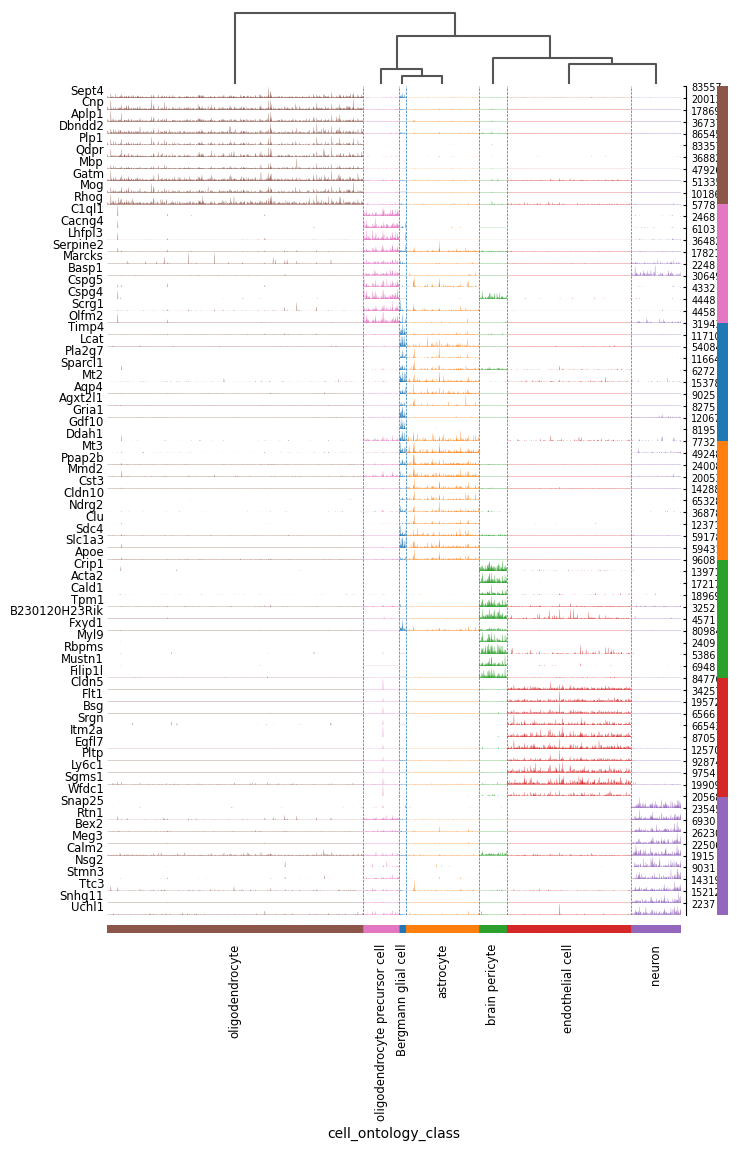

In [90]:
# identify the top expresing genes per cell class based on the normalized data.
sc.tl.rank_genes_groups(adata_cpm, groupby='cell_ontology_class', method='t-test_overestim_var', n_genes=10 )
# plot the genes
sc.pl.rank_genes_groups_tracksplot(adata_cpm, groupby='cell_ontology_class', figsize=(8,12), dendrogram=True, cmap='Blues')
plt.show()

In [95]:
adata_cpm

AnnData object with n_obs × n_vars = 3210 × 18585
    obs: 'cell_ontology_class', 'subtissue', 'mouse.sex', 'mouse.id', 'plate.barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ERCC', 'log1p_total_counts_ERCC', 'pct_counts_ERCC', 'n_counts'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'n_counts'
    uns: 'pca', 'mouse.id_colors', 'rank_genes_groups', 'cell_ontology_class_colors', 'dendrogram_cell_ontology_class'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None

In [104]:
df_top_genes1 = pd.DataFrame({
    group: adata_cpm.uns['rank_genes_groups']['names'][group]
    for group in groups
})
df_top_genes1

,Bergmann glial cell,astrocyte,brain pericyte,endothelial cell,neuron,oligodendrocyte,oligodendrocyte precursor cell
0,Timp4,Mt3,Crip1,Cldn5,Snap25,Sept4,C1ql1
1,Lcat,Ppap2b,Acta2,Flt1,Rtn1,Cnp,Cacng4
2,Pla2g7,Mmd2,Cald1,Bsg,Bex2,Aplp1,Lhfpl3
3,Sparcl1,Cst3,Tpm1,Srgn,Meg3,Dbndd2,Serpine2
4,Mt2,Cldn10,B230120H23Rik,Itm2a,Calm2,Plp1,Marcks
5,Aqp4,Ndrg2,Fxyd1,Egfl7,Nsg2,Qdpr,Basp1
6,Agxt2l1,Clu,Myl9,Pltp,Stmn3,Mbp,Cspg5
7,Gria1,Sdc4,Rbpms,Ly6c1,Ttc3,Gatm,Cspg4
8,Gdf10,Slc1a3,Mustn1,Sgms1,Snhg11,Mog,Scrg1
9,Ddah1,Apoe,Filip1l,Wfdc1,Uchl1,Rhog,Olfm2


# The top 10 expressed gene per cell class is not altered by data filtering and normalization.